# 16 · E2b: does the fitted program survive a change of *equations*? A spiking realization

**Where E2 left off (Notebook 05).** The fitted L1 is invariant across *numerical* substrates (Euler, RK4, Brian2: gap ≈ 0.001 × noise) and has a negative Lyapunov exponent. But all those substrates share its equations. E2 also found that the computation lives in **small deviations around rest**: it needs ~12 fractional bits of state.

**E2b changes the equations.** Each graded unit of L1 keeps its input variable V, but its output nonlinearity and its synapses are carried by a **population of M spiking neurons**, compiled in the style of the Neural Engineering Framework: decoders are solved so that the population's firing approximates the unit's sigmoid. Three substrates separate the two ways this can fail:

| substrate | what it has | error source |
|---|---|---|
| `lif_rate` | M leaky integrate-and-fire tuning curves, analytic rates, no spikes | decoding (tuning curves only approximate the sigmoid) |
| `poisson` | M Poisson neurons firing at r_max × sigmoid: exact mean | spike noise only |
| `lif` | M spiking LIF neurons (τ_m 20 ms, refractory 2 ms, heterogeneous) | both |

The question is quantitative: **how many spiking neurons does one graded unit of the fitted program need** before its interventional responses are indistinguishable from the original? *C. elegans* neurons are mostly graded, so this is a test of the program's substrate independence, not a model of the worm.

**What the synthetic checks showed while building this** (a known L1 on a 30-neuron random wiring):
* **The represented range must cover saturation.** At rest, many units sit far outside the sigmoid's transition (x = k(V − θ) from −18 to +17). LIF tuning curves extrapolate badly there, so the input is clipped to ±8, where the sigmoid is within 3×10⁻⁴ of its limits. Without this, decoding never converged: gap/noise stayed at ~6–8 for any M.
* **The right reference is the continuous-time model.** The spiking substrates run in continuous time, and on the synthetic worm the fitted Euler model (dt = 0.2 s) differs from its own continuous-time version by 0.29 × noise. Every comparison is therefore against `ode`: the same fitted equations, RK4 with dt = 0.02 s, as in Notebook 05. On your real fits this difference was 0.0012–0.0015, so `ref` is reported alongside.
* **Compiler trade-off.** Tighter decoders fit the sigmoid better but amplify spike noise. With regularisation 0.01, `lif` reached gap 0.58 at M = 300; with 0.001 it reached 1.39. The registered compiler uses 0.01.
* **Regular spikes are cheaper than random ones.** On the synthetic worm, `poisson` needed ~10⁴ neurons per unit for gap < 0.4, while `lif` reached 0.58 with 300.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, pickle, time, datetime, numpy as np, matplotlib.pyplot as plt, jax
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 14, 0), \
    f"Notebook 16 needs closurebench >= 0.14.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_, substrates as SB, spiking as SP
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {"smoke":  dict(N_COLS=10, FOLDS_USED=1, GRID={"lif_rate": (30, 100, 300), "poisson": (100, 1000, 10000), "lif": (30, 100)}),
        "laptop": dict(N_COLS=40, FOLDS_USED=2, GRID={"lif_rate": (10, 30, 100, 300, 1000), "poisson": (100, 1000, 10000, 100000), "lif": (30, 100, 300, 1000)}),
        "full":   dict(N_COLS=None, FOLDS_USED=None, GRID={"lif_rate": (10, 30, 100, 300, 1000), "poisson": (100, 1000, 10000, 100000), "lif": (30, 100, 300, 1000, 3000)})}[MODE]
globals().update(CONF)
REG, GAP_MAX, DFEVE_MAX = 0.01, 0.1, 0.05
TAG = "" if MODE == "full" else f"_{MODE}"

# ---- the fitted L1 models of Notebook 04 (as in Notebook 05); smoke falls back to a synthetic L1 if they are absent
E1_TAG = "_laptop" if MODE == "smoke" else TAG
try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    e1_plan = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))
    assert e1_result["L_star"] == "L1", "spiking.py implements L1"
    c = e1_plan["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"])
    ck1 = os.path.join(RESULTS, f"e1_checkpoints{E1_TAG}")
    models = [pickle.load(open(os.path.join(ck1, f"fold{f}_L1_final.pkl"), "rb"))["params"] for f in range(c["k_folds"])]
    SOURCE = f"E1 fits ({E1_TAG.strip('_') or 'full'})"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("E1 fits not found (", err, ") -> smoke test on a synthetic L1")
    ds, p_true, _ = lad.make_synthetic(lad.random_wiring(N=30, S=10, seed=1, strains=("wt",)), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = [None]; models = [p_true]; SOURCE = "synthetic L1"
rng = np.random.default_rng(0)
COLS = np.sort(rng.choice(ds.S, N_COLS, replace=False)) if N_COLS and N_COLS < ds.S else np.arange(ds.S)
FOLDS = list(range(len(models)))[:FOLDS_USED] if FOLDS_USED else list(range(len(models)))
CK = os.path.join(RESULTS, "e2b_ck", MODE); os.makedirs(CK, exist_ok=True)
print(f"source: {SOURCE} | {ds.N} neurons | {len(COLS)} stimuli | fold models {FOLDS}")
for kind, Ms in GRID.items():
    print(f"  {kind:8s} M = {Ms}")

source: E1 fits (laptop) | 120 neurons | 40 stimuli | fold models [0, 1]
  lif_rate M = (10, 30, 100, 300, 1000)
  poisson  M = (100, 1000, 10000, 100000)
  lif      M = (30, 100, 300, 1000)


### Pre-registration (before §1)

Recorded in `results/E2b_preregistration*.json`.

**Reference.** `ode` is the same fitted L1 in continuous time (RK4, dt = 0.02 s). The spiking substrates are continuous-time too, so only the substrate differs. The Euler fit `ref` is reported alongside.

* **Pass** at (substrate, M): gap/noise < 0.1 **and** |ΔFEVE| < 0.05 against `ode`, for every fold model used. These are E2's thresholds; ΔFEVE is computed on each fold's held-out pairs.
* **M\*** for each substrate is the smallest M that passes.
* **SPIKING_TRANSFER:** `lif` passes at some M in the grid. The fitted program then has a spiking realization, and is substrate-independent at the level of equations too, given enough neurons.
* The compiler is fixed in advance: 50 % on/off encoders, intercepts uniform on ±0.95 × 8, maximal rates 60–150 Hz, decoder regularisation 0.01 × max rate, inputs clipped to ±8. Poisson neurons fire at r_max = 100 Hz.
* Descriptive: the scaling exponent of gap/noise in M (log–log fit) for each substrate, and the spike-efficiency ratio M\*_poisson / M\*_lif.

In [3]:
prereg = os.path.join(RESULTS, f"E2b_preregistration{TAG}.json")
plan = {"experiment": "E2b spiking realization", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "source": SOURCE, "config": {"N_COLS": int(len(COLS)), "folds": FOLDS, "grid": {k: list(v) for k, v in GRID.items()}, "reg": REG},
        "pass": f"gap/noise < {GAP_MAX} and |dFEVE| < {DFEVE_MAX} vs ode (RK4 dt 0.02), every fold model used",
        "SPIKING_TRANSFER": "lif passes at some M in the grid",
        "compiler": "on/off encoders, intercepts U(+-0.95*8), rmax U(60,150) Hz, ridge 0.01*max rate, inputs clipped to +-8; poisson rmax 100 Hz"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E2b_preregistration_laptop.json


## 1 · References: the fitted model in discrete and continuous time

In [4]:
E, R_ref, R_ode = {}, {}, {}
for f in FOLDS:
    p = jax.tree_util.tree_map(jax.numpy.asarray, models[f])
    E[f] = SB.effective_params("L1", p, st, COLS)
    R_ref[f] = np.asarray(lad.predict("L1", p, st, ds.stim[COLS], ds.strains, cfg, COLS))[0]
    R_ode[f] = SB.simulate_numpy(E[f], ds.stim[COLS], cfg, "rk4", dt=0.02)
    print(f"fold {f}: ode vs ref gap/noise {SB.substrate_gap(R_ode[f], R_ref[f], ds, COLS):.4f}")
for kind in ("poisson", "lif"):
    for Mn in GRID[kind][-1:]:
        print(f"estimated time for one {kind} run at M = {Mn}: {SP.estimate_seconds(E[FOLDS[0]], len(COLS), cfg, kind, Mn) / 60:.1f} min")

fold 0: ode vs ref gap/noise 0.0011
fold 1: ode vs ref gap/noise 0.0012
estimated time for one poisson run at M = 100000: 0.1 min
estimated time for one lif run at M = 1000: 21.0 min


## 2 · The sweep (checkpointed)

Every (fold, substrate, M) run is saved as soon as it finishes, so a re-run resumes. The `lif` runs at the largest M dominate the time; see the estimate above.

In [5]:
def test_mask(f):
    return None if folds[f] is None else folds[f]
rows = []
for f in FOLDS:
    for kind, Ms in GRID.items():
        for Mn in Ms:
            ck = os.path.join(CK, f"fold{f}_{kind}_M{Mn}.npy")
            t0 = time.time()
            if os.path.exists(ck):
                Rs = np.load(ck)
            else:
                pop = SP.make_population(Mn, seed=f, reg=REG) if kind != "poisson" else None
                Rs = SP.simulate_spiking(E[f], ds.stim[COLS], cfg, kind=kind, M=Mn, pop=pop, seed=f)
                np.save(ck, Rs)
            tm = test_mask(f)
            r = dict(fold=f, kind=kind, M=Mn,
                     gap=SB.substrate_gap(Rs, R_ode[f], ds, COLS), gap_ref=SB.substrate_gap(Rs, R_ref[f], ds, COLS),
                     dfeve=SB.feve_on(Rs, ds, COLS, tm) - SB.feve_on(R_ode[f], ds, COLS, tm))
            rows.append(r)
            print(f"fold {f} {kind:8s} M {Mn:6d}: gap/noise {r['gap']:8.3f} (vs ref {r['gap_ref']:8.3f}) dFEVE {r['dfeve']:+.3f}  ({time.time() - t0:.0f} s)", flush=True)

fold 0 lif_rate M     10: gap/noise    0.065 (vs ref    0.058) dFEVE -0.076  (2 s)
fold 0 lif_rate M     30: gap/noise    0.105 (vs ref    0.100) dFEVE -0.086  (6 s)
fold 0 lif_rate M    100: gap/noise    0.008 (vs ref    0.007) dFEVE -0.026  (24 s)
fold 0 lif_rate M    300: gap/noise    0.002 (vs ref    0.003) dFEVE -0.008  (67 s)
fold 0 lif_rate M   1000: gap/noise    0.001 (vs ref    0.002) dFEVE +0.000  (265 s)
fold 0 poisson  M    100: gap/noise    0.032 (vs ref    0.033) dFEVE -0.020  (13 s)
fold 0 poisson  M   1000: gap/noise    0.004 (vs ref    0.005) dFEVE -0.003  (15 s)
fold 0 poisson  M  10000: gap/noise    0.000 (vs ref    0.001) dFEVE -0.000  (15 s)
fold 0 poisson  M 100000: gap/noise    0.000 (vs ref    0.001) dFEVE +0.001  (14 s)
fold 0 lif      M     30: gap/noise    0.077 (vs ref    0.070) dFEVE -0.056  (30 s)
fold 0 lif      M    100: gap/noise    0.011 (vs ref    0.010) dFEVE -0.018  (131 s)
fold 0 lif      M    300: gap/noise    0.007 (vs ref    0.007) dFEVE -0.001 

## 3 · How many spiking neurons does a graded unit need?

lif_rate M* = 100 | gap/noise ~ M^-1.36
poisson  M* = 100 | gap/noise ~ M^-0.98
lif      M* = 100 | gap/noise ~ M^-1.25
spike efficiency: Poisson needs 1x as many neurons as LIF
Registered rule -> SPIKING_TRANSFER (lif passes at some M): True


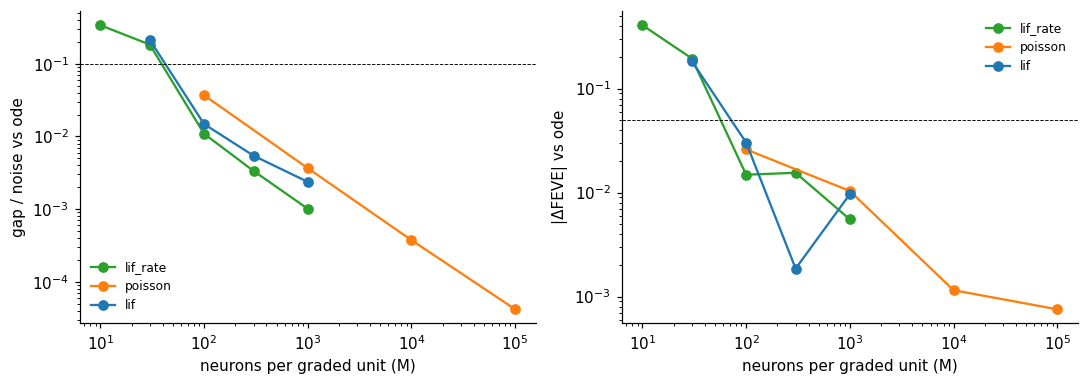

In [6]:
passes = lambda r: r["gap"] < GAP_MAX and abs(r["dfeve"]) < DFEVE_MAX
MSTAR, SLOPE = {}, {}
for kind, Ms in GRID.items():
    ok_M = [Mn for Mn in Ms if all(passes(r) for r in rows if r["kind"] == kind and r["M"] == Mn)]
    MSTAR[kind] = min(ok_M) if ok_M else None
    g = np.array([[np.mean([r["gap"] for r in rows if r["kind"] == kind and r["M"] == Mn])] for Mn in Ms]).ravel()
    SLOPE[kind] = float(np.polyfit(np.log10(Ms), np.log10(np.maximum(g, 1e-6)), 1)[0]) if len(Ms) > 1 else float("nan")
    print(f"{kind:8s} M* = {MSTAR[kind] if MSTAR[kind] else '> ' + str(max(Ms))} | gap/noise ~ M^{SLOPE[kind]:+.2f}")
SPIKING_TRANSFER = MSTAR["lif"] is not None
if MSTAR["poisson"] and MSTAR["lif"]:
    print(f"spike efficiency: Poisson needs {MSTAR['poisson'] / MSTAR['lif']:.0f}x as many neurons as LIF")
print("Registered rule -> SPIKING_TRANSFER (lif passes at some M):", SPIKING_TRANSFER)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for kind, c in (("lif_rate", "tab:green"), ("poisson", "tab:orange"), ("lif", "tab:blue")):
    Ms = GRID[kind]
    ax[0].plot(Ms, [np.mean([r["gap"] for r in rows if r["kind"] == kind and r["M"] == Mn]) for Mn in Ms], "o-", c=c, label=kind)
    ax[1].plot(Ms, [np.mean([abs(r["dfeve"]) for r in rows if r["kind"] == kind and r["M"] == Mn]) for Mn in Ms], "o-", c=c, label=kind)
ax[0].axhline(GAP_MAX, c="k", ls="--", lw=0.6); ax[1].axhline(DFEVE_MAX, c="k", ls="--", lw=0.6)
for a, lab in zip(ax, ("gap / noise vs ode", "|ΔFEVE| vs ode")):
    a.set_xscale("log"); a.set_yscale("log"); a.set_xlabel("neurons per graded unit (M)"); a.set_ylabel(lab); a.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

In [7]:
out = {"source": SOURCE, "M_star": MSTAR, "slope": SLOPE, "spiking_transfer": SPIKING_TRANSFER, "rows": rows,
       "ode_vs_ref": {str(f): SB.substrate_gap(R_ode[f], R_ref[f], ds, COLS) for f in FOLDS}}
json.dump(out, open(os.path.join(RESULTS, f"E2b_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E2b_result{TAG}.json")

saved E2b_result_laptop.json


## 4 · Reading the result

| outcome | reading for C2 |
|---|---|
| `lif` passes at modest M (≤ ~300) | The fitted program has a spiking realization: it is software with respect to the *equations* as well as the integrator. M\* is the hardware redundancy its precision needs (E2's 12 fractional bits of state, expressed as neurons). |
| `lif` passes only at large M, or `lif_rate` passes but `lif` does not | The program survives a change of equations only if spike noise is averaged away. It lives in small deviations that a few spiking neurons cannot carry. "Software" here needs a large, redundant substrate. |
| `lif_rate` fails | The program depends on the exact *shape* of its nonlinearity. That makes it closer to hardware: it is defined by the sigmoid, not by a computation that tuning curves can approximate. |

**Limits.**
* Only the nonlinearity and the synapse are spiking; the graded input variable V of each unit is kept. A fully spiking realization would also implement V's integration with recurrent populations.
* One compiler. A better one, e.g. decoders optimised for the slope near each unit's operating point, could lower M\*. M\* is therefore an upper bound.
* Single trials with independent spike noise per stimulation; the atlas averages trials, so a substrate could also average.